# 💎 Diamond Price Prediction & Market Segmentation
Regression, ANN, and Clustering

In [1]:
# Install libraries
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost tensorflow joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import joblib


In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\Dipika\Downloads\diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Data cleaning
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
df.dropna(inplace=True)
df.shape

(53920, 10)

In [5]:
#outliers handling
from scipy.stats import zscore
import numpy as np

# Numerical columns
numerical_cols = ['carat', 'price', 'x', 'y', 'z']

# Calculate Z-scores
z_scores = np.abs(zscore(df[numerical_cols]))

# Threshold
threshold = 3

# Remove outliers
df_clean = df[(z_scores < threshold).all(axis=1)]

# Shapes
print("Original Dataset Shape:", df.shape)

print("Dataset Shape After Outlier Removal:", df_clean.shape)

Original Dataset Shape: (53920, 10)
Dataset Shape After Outlier Removal: (52502, 10)


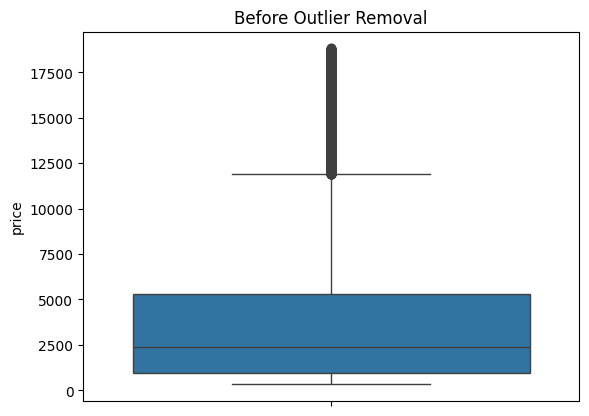

In [6]:
sns.boxplot(df['price'])

plt.title("Before Outlier Removal")

plt.show()

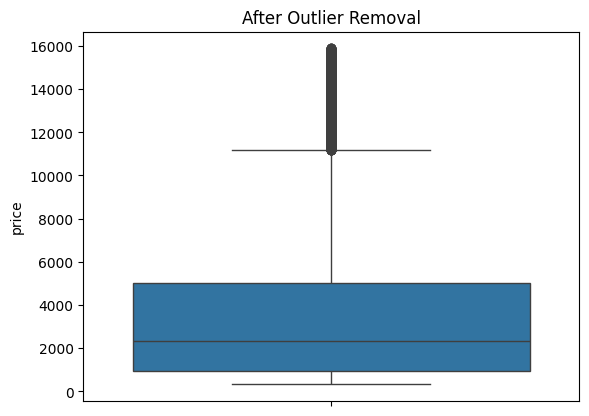

In [7]:
sns.boxplot(df_clean['price'])

plt.title("After Outlier Removal")

plt.show()

In [8]:
# Numerical columns
numerical_cols = ['carat', 'price', 'x', 'y', 'z']

# Check skewness
print(df[numerical_cols].skew())

carat    1.116207
price    1.618349
x        0.398348
y        2.462211
z        1.585490
dtype: float64


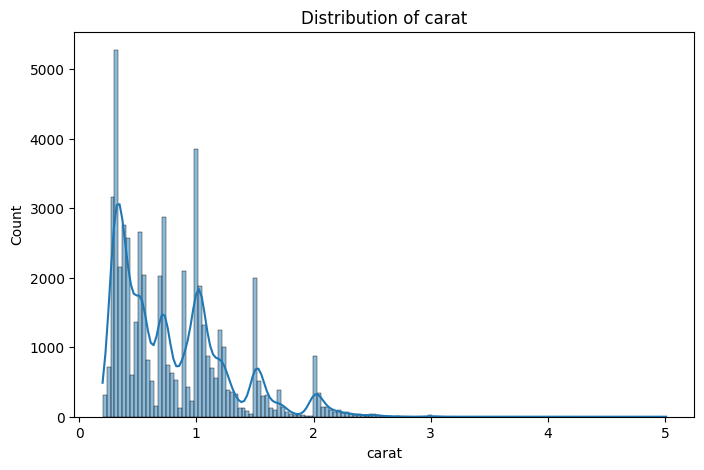

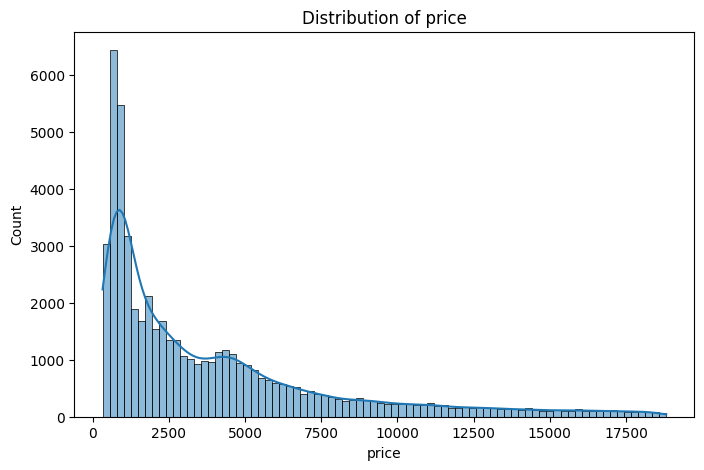

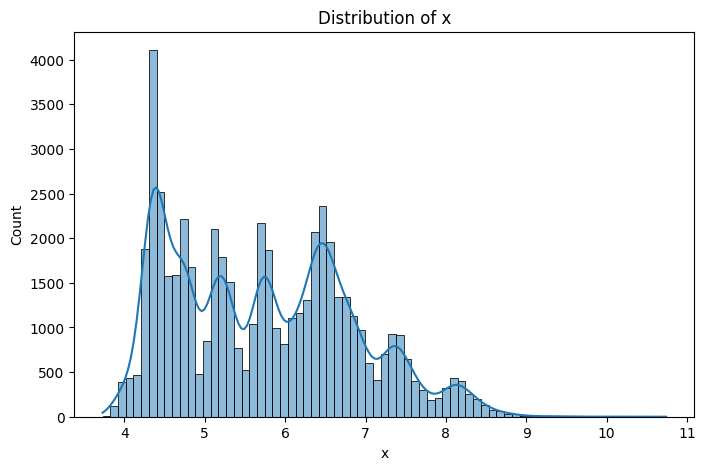

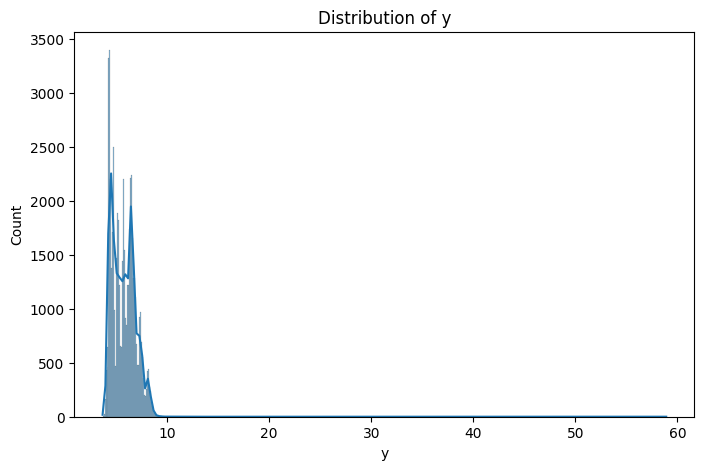

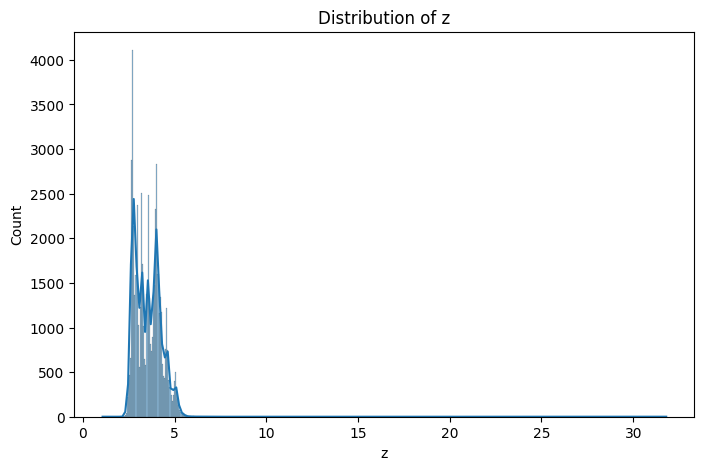

In [9]:
#visualise skewness
numerical_cols = ['carat', 'price', 'x', 'y', 'z']

for col in numerical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

In [10]:
import numpy as np

skewed_cols = ['price', 'carat', 'x', 'y', 'z']

for col in skewed_cols:
    
    df[col] = np.sqrt(df[col])

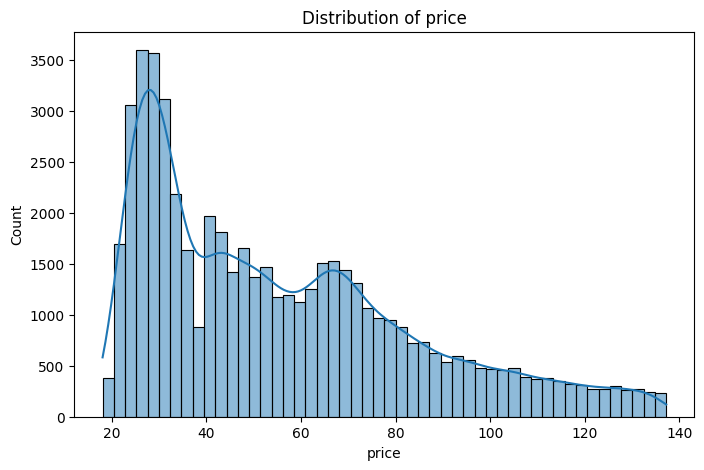

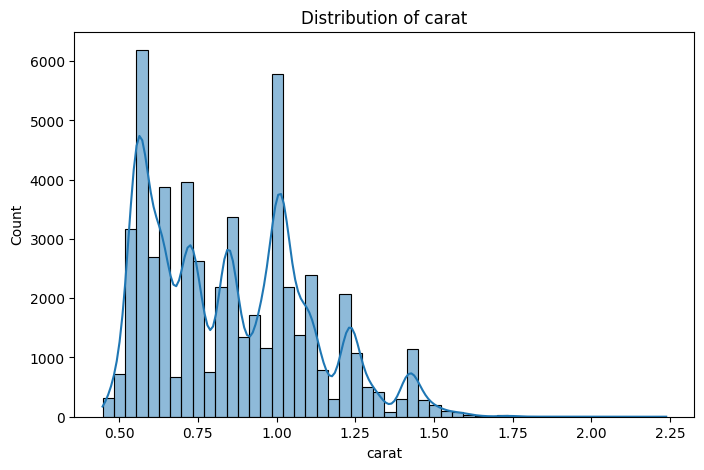

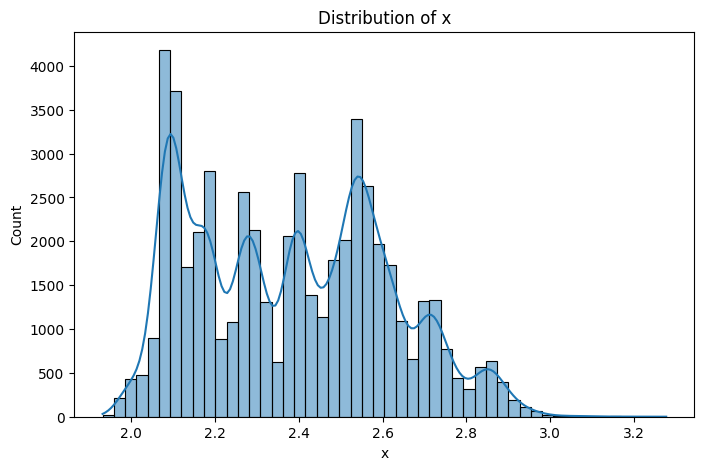

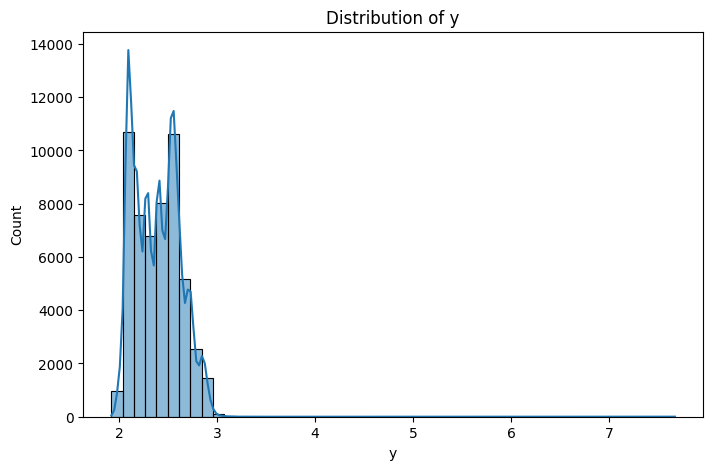

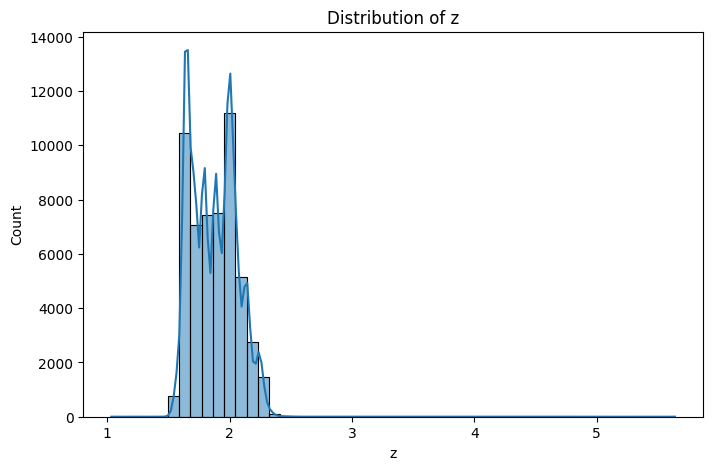

In [11]:
#EDA
columns = ['price', 'carat', 'x', 'y', 'z']

for col in columns:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], kde=True, bins=50)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

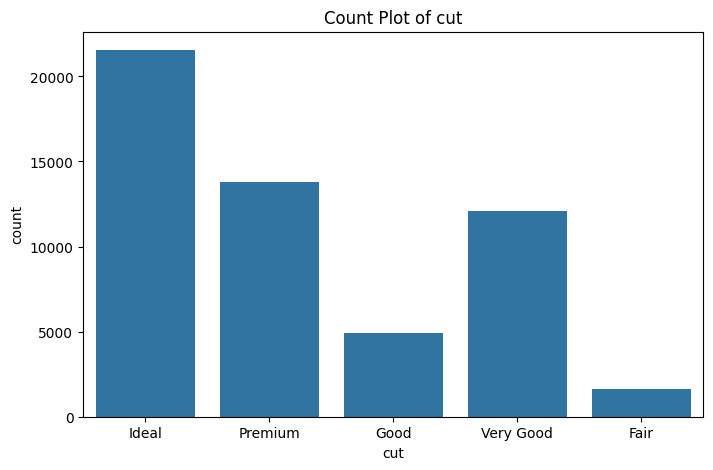

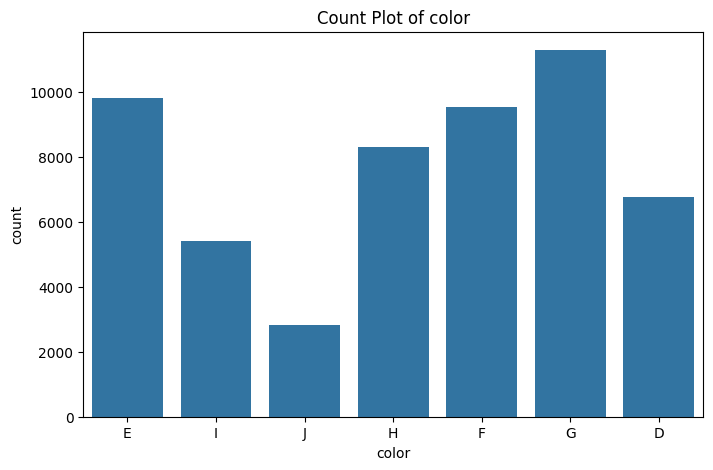

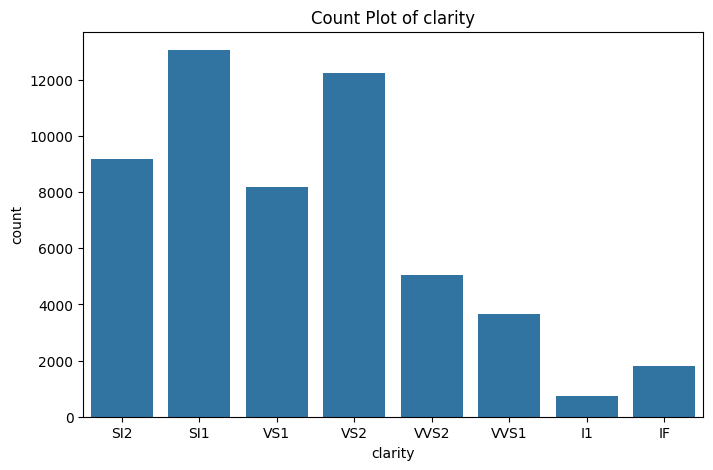

In [12]:
categorical_cols = ['cut', 'color', 'clarity']

for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.countplot(x=col, data=df)
    
    plt.title(f"Count Plot of {col}")
    
    plt.show()

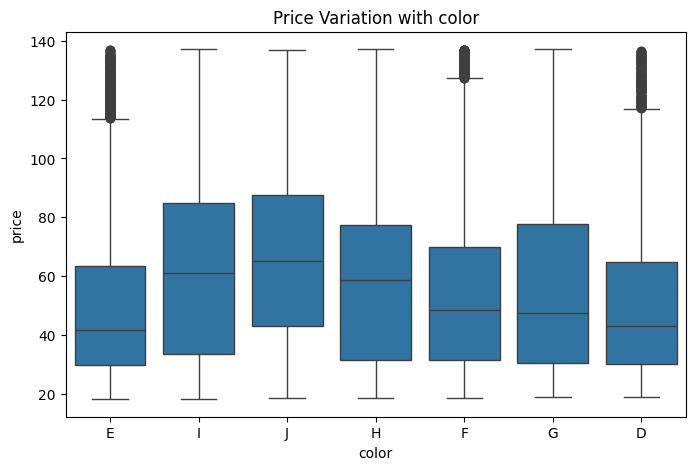

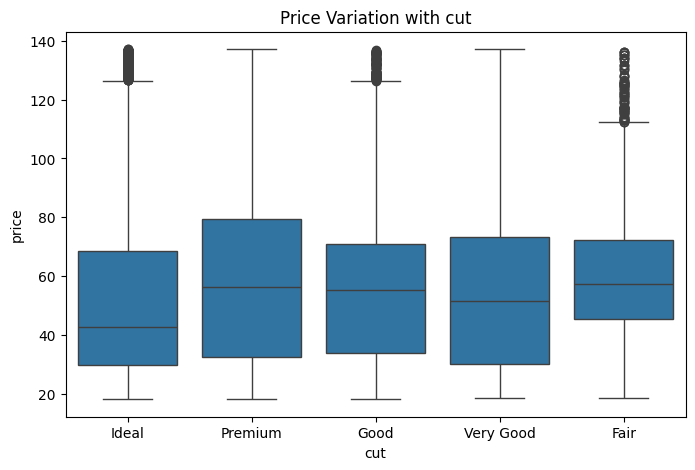

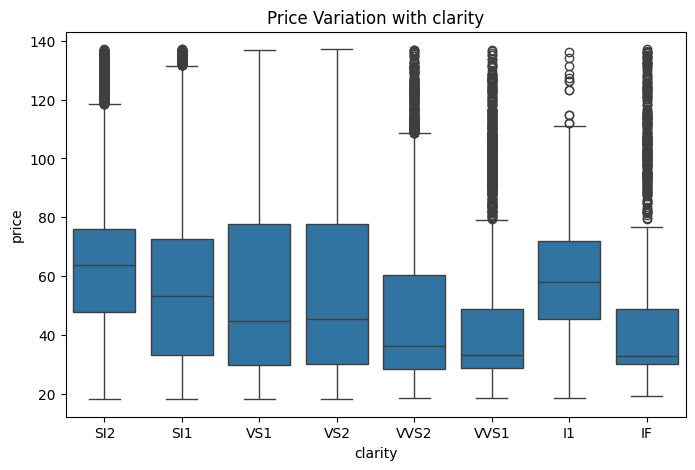

In [13]:
categorical_cols = ['color', 'cut', 'clarity']

for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.boxplot(x=col, y='price', data=df)
    
    plt.title(f"Price Variation with {col}")
    
    plt.show()

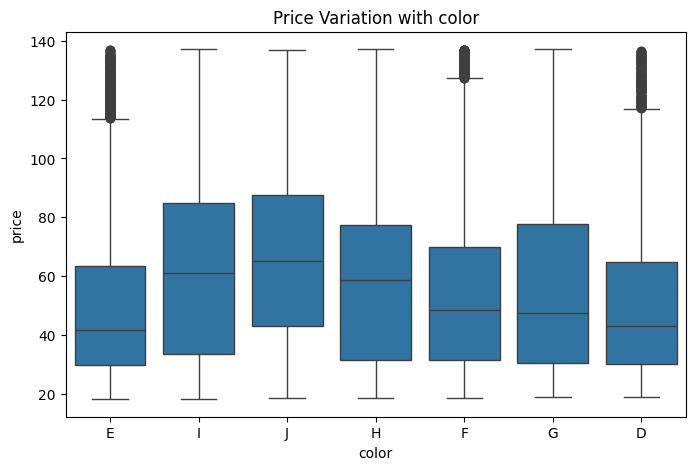

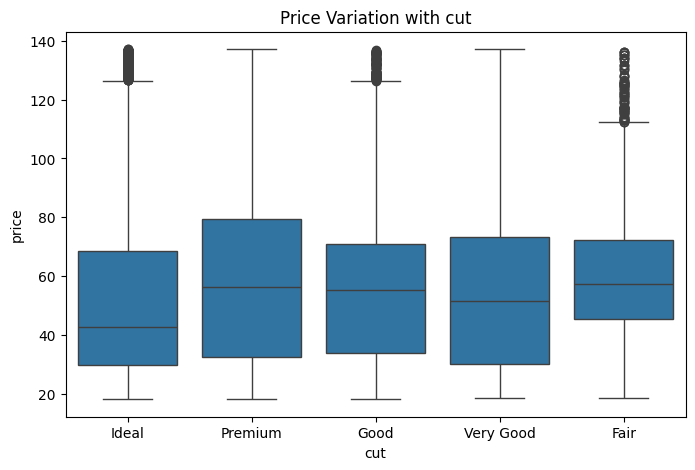

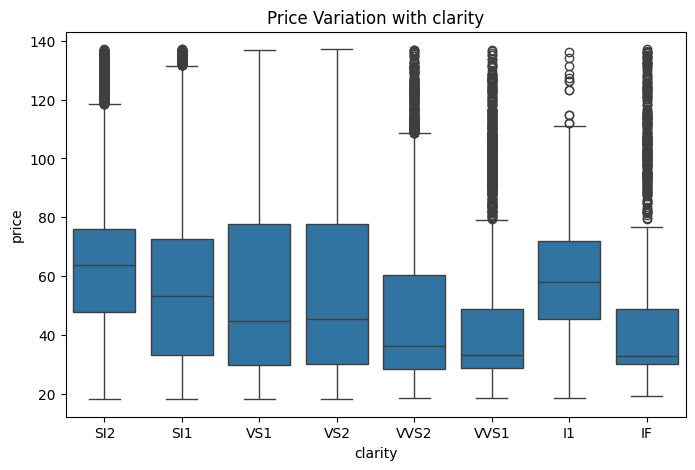

In [14]:
categorical_cols = ['color', 'cut', 'clarity']

for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.boxplot(x=col, y='price', data=df)
    
    plt.title(f"Price Variation with {col}")
    
    plt.show()

In [ ]:
sns.pairplot(
    df[['carat', 'x', 'y', 'z', 'price']],
    diag_kind='kde',
    corner=True
)

plt.show()

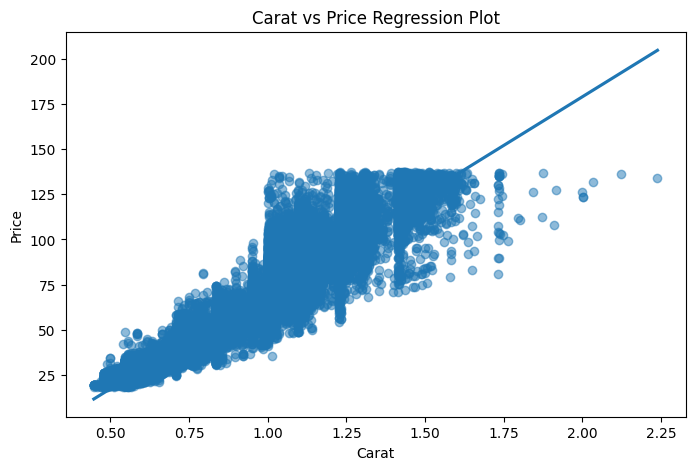

In [16]:
# Carat vs Price Regression Plot

plt.figure(figsize=(8,5))

sns.regplot(
    x='carat',
    y='price',
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title("Carat vs Price Regression Plot")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()

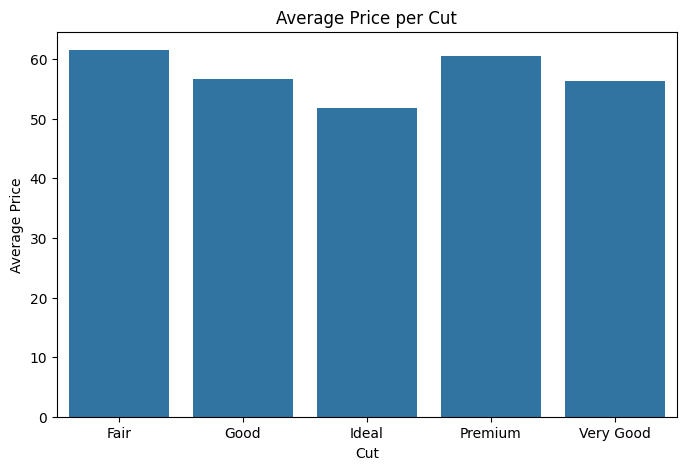

In [17]:
plt.figure(figsize=(8,5))

avg_cut_price = df.groupby('cut')['price'].mean().reset_index()

sns.barplot(
    x='cut',
    y='price',
    data=avg_cut_price
)

plt.title("Average Price per Cut")
plt.xlabel("Cut")
plt.ylabel("Average Price")

plt.show()

In [18]:
# Feature Engineering
df['price_inr'] = df['price'] * 83
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x']+df['y'])/(2*df['z'])

In [19]:
# Encoding
encoder = OrdinalEncoder()
df[['cut','color','clarity']] = encoder.fit_transform(df[['cut','color','clarity']])

In [20]:
# Train Test Split
X = df.drop('price',axis=1)
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_test_predict = lin_model.predict(X_test)
rmse = (np.sqrt(mean_squared_error(y_test,y_test_predict)))

In [23]:
y_test_predict

array([ 29.563491  ,  96.29641738, 108.36512354, ...,  94.02127419,
        23.23790008,  40.79215611], shape=(10784,))

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Train Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, dt_pred))

rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
print("RMSE:", rmse)

R2 Score: 0.9999999457771122
RMSE: 0.006679818653623918


In [25]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, rf_pred))

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print("RMSE:", rmse)

R2 Score: 0.9999999803893547
RMSE: 0.00401716151326191


In [26]:
# Train XGBoost
model = XGBRegressor()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print('R2 Score:', r2_score(y_test,pred))
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)

R2 Score: 0.9999597140405679
RMSE: 0.1820749526237989


In [27]:
# Save Model
joblib.dump(model,'diamond_price_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(encoder,'encoder.pkl')

['encoder.pkl']

In [28]:
cluster_df = df.drop('price',axis=1)



In [29]:
# =========================================================
# DIAMOND CLUSTERING
# =========================================================

import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ---------------------------------------------------------
# SELECT FEATURES FOR CLUSTERING
# ---------------------------------------------------------

cluster_features = [
    'carat',
    'cut',
    'color',
    'clarity',
    'depth',
    'table',
    'x',
    'y',
    'z'
]

cluster_df = df[cluster_features].copy()


# ---------------------------------------------------------
# SCALE FEATURES
# ---------------------------------------------------------

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(
    cluster_df
)


# ---------------------------------------------------------
# FIND BEST NUMBER OF CLUSTERS
# ---------------------------------------------------------

scores = []

for k in range(2, 10):

    temp_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = temp_kmeans.fit_predict(
        cluster_scaled
    )

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    scores.append(score)

    print(
        f"K = {k}, Silhouette Score = {score:.4f}"
    )


# ---------------------------------------------------------
# FINAL K-MEANS
# ---------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(
    cluster_scaled
)

df['cluster'] = cluster


# ---------------------------------------------------------
# SAVE CLUSTER MODEL
# ---------------------------------------------------------

joblib.dump(
    kmeans,
    "cluster_model.pkl"
)

joblib.dump(
    cluster_scaler,
    "cluster_scaler.pkl"
)

print("Cluster model saved successfully!")

K = 2, Silhouette Score = 0.2991
K = 3, Silhouette Score = 0.2020
K = 4, Silhouette Score = 0.2020
K = 5, Silhouette Score = 0.1642
K = 6, Silhouette Score = 0.1739
K = 7, Silhouette Score = 0.1708
K = 8, Silhouette Score = 0.1698
K = 9, Silhouette Score = 0.1680
Cluster model saved successfully!


In [30]:
df.shape


(53920, 15)

In [31]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z,price_inr,volume,price_per_carat,dimension_ratio,cluster
0,0.479583,2.0,1.0,3.0,61.5,55.0,18.055470,1.987461,1.994994,1.558846,1498.604017,6.180779,37.648258,1.277373,1
1,0.458258,3.0,1.0,2.0,59.8,61.0,18.055470,1.972308,1.959592,1.519868,1498.604017,5.874169,39.400266,1.293500,1
2,0.479583,1.0,1.0,4.0,56.9,65.0,18.083141,2.012461,2.017424,1.519868,1500.900730,6.170647,37.705956,1.325735,1
3,0.538516,3.0,5.0,5.0,62.4,58.0,18.275667,2.049390,2.056696,1.621727,1516.880351,6.835538,33.937061,1.265961,1
4,0.556776,1.0,6.0,3.0,63.3,58.0,18.303005,2.083267,2.085665,1.658312,1519.149433,7.205363,32.873168,1.256980,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.848528,2.0,0.0,2.0,60.8,57.0,52.507142,2.397916,2.400000,1.870829,4358.092817,10.766615,61.880261,1.282297,2
53936,0.848528,1.0,0.0,2.0,63.1,55.0,52.507142,2.385372,2.397916,1.900000,4358.092817,10.867851,61.880261,1.258760,2
53937,0.836660,4.0,0.0,2.0,62.8,60.0,52.507142,2.379075,2.383275,1.886796,4358.092817,10.698118,62.758039,1.262020,2
53938,0.927362,3.0,4.0,3.0,61.0,58.0,52.507142,2.479919,2.473863,1.933908,4358.092817,11.864490,56.619908,1.280770,2


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib

# FEATURES AND TARGET
X = df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]

y = df['price']

# PIPELINE
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBRegressor())
])

# TRAIN
pipeline.fit(X, y)

# SAVE
joblib.dump(pipeline, "pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!
